In [1]:
# ============================================================
# Notebook 06 — XGBoost Modelling
# Baseline V1: Simple lag features (1, 2, 3, 12 months)
# Reference: Chen & Guestrin (2016)
# Implementation: xgboost library
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all four series
ndvi_amazon_train = pd.read_csv(PROCESSED / 'ndvi_amazon_train.csv', parse_dates=['date'])
ndvi_amazon_test = pd.read_csv(PROCESSED / 'ndvi_amazon_test.csv', parse_dates=['date'])

ndvi_sahel_train = pd.read_csv(PROCESSED / 'ndvi_sahel_train.csv', parse_dates=['date'])
ndvi_sahel_test = pd.read_csv(PROCESSED / 'ndvi_sahel_test.csv', parse_dates=['date'])

sst_atlantic_train = pd.read_csv(PROCESSED / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test = pd.read_csv(PROCESSED / 'sst_atlantic_test.csv', parse_dates=['date'])

sst_indian_train = pd.read_csv(PROCESSED / 'sst_indian_train.csv', parse_dates=['date'])
sst_indian_test = pd.read_csv(PROCESSED / 'sst_indian_test.csv', parse_dates=['date'])

print("All series loaded successfully")

All series loaded successfully


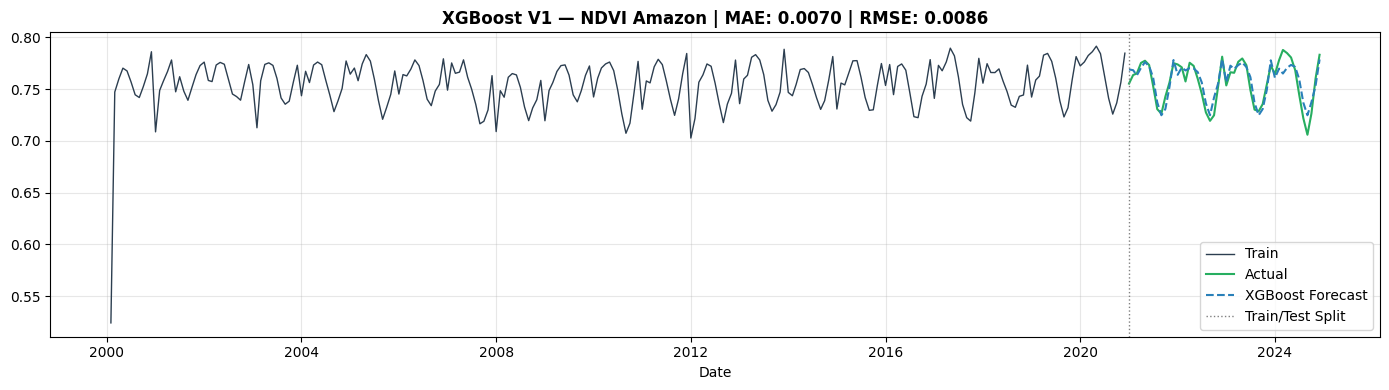

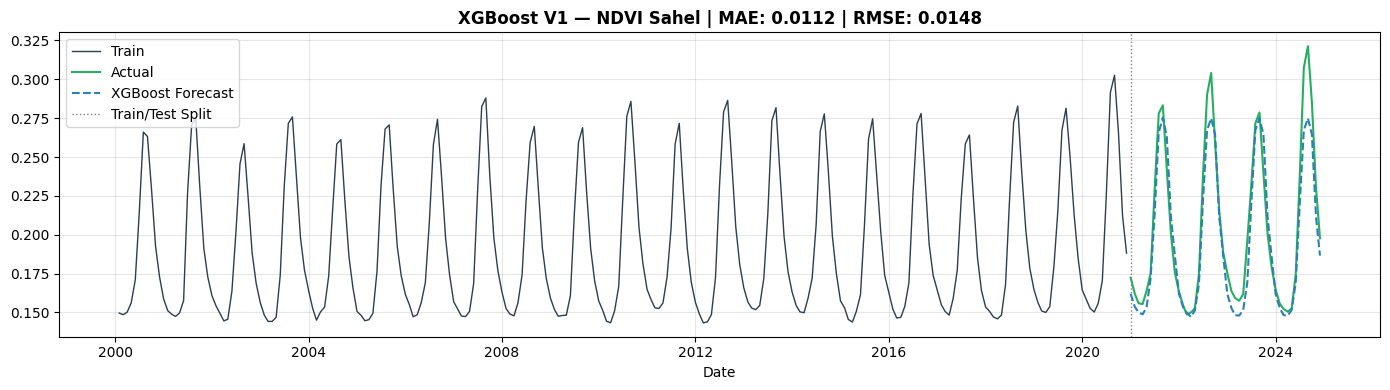

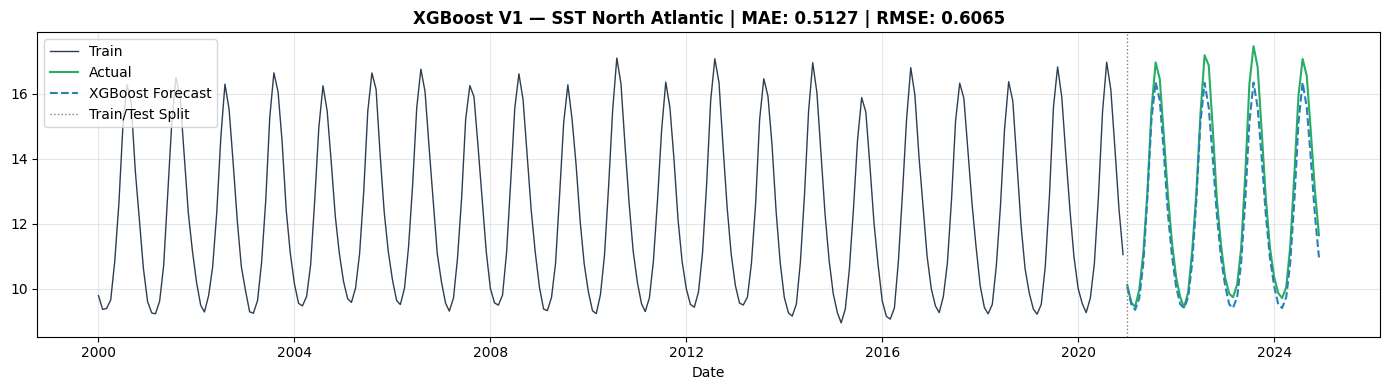

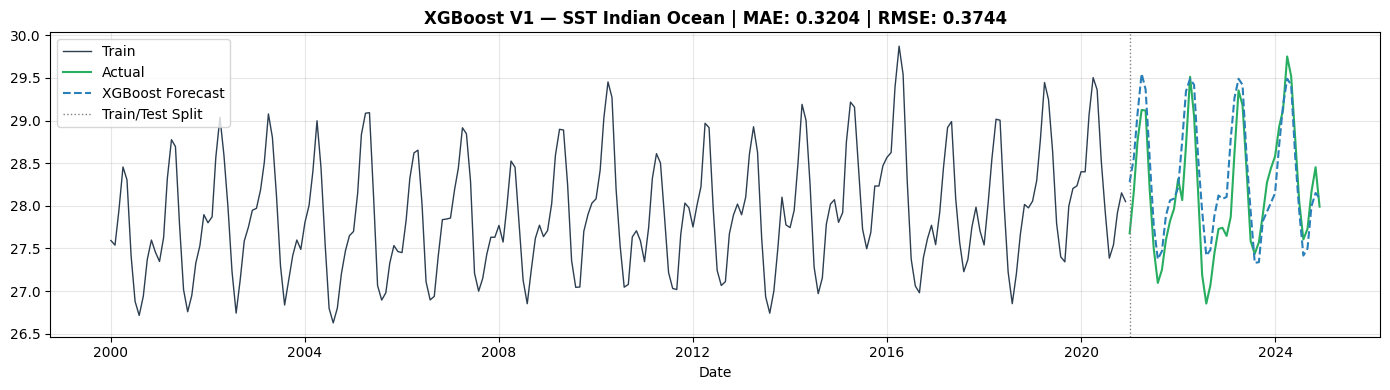


=== XGBoost V1 Baseline Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0070 0.0086
        NDVI Sahel 0.0112 0.0148
SST North Atlantic 0.5127 0.6065
  SST Indian Ocean 0.3204 0.3744


In [2]:
# ============================================================
# XGBoost V1 — Baseline with simple lag features
# Lags: 1, 2, 3, 12 months + month of year
# No native time awareness — time encoded via features
# Recursive forecasting for multi-step ahead prediction
# ============================================================

def create_lag_features(df, value_col, lags=[1, 2, 3, 12]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df[value_col].shift(lag)
    df['month'] = df['date'].dt.month
    df = df.dropna()
    return df

def run_xgboost(train, test, value_col, series_name, lags=[1, 2, 3, 12]):
    # Combine train and test for feature creation
    full = pd.concat([train, test]).reset_index(drop=True)
    full = create_lag_features(full, value_col, lags)
    
    feature_cols = [f'lag_{l}' for l in lags] + ['month']
    
    # Split back after feature creation
    train_feat = full[full['date'] <= train['date'].max()]
    test_feat = full[full['date'] >= test['date'].min()]
    
    X_train = train_feat[feature_cols]
    y_train = train_feat[value_col]
    X_test = test_feat[feature_cols]
    actual = test_feat[value_col].values
    
    # Fit model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)
    
    # Recursive forecasting
    forecast = []
    history = list(train[value_col].values)
    
    for i in range(len(test)):
        row = {}
        for lag in lags:
            row[f'lag_{lag}'] = history[-lag] if lag <= len(history) else history[0]
        row['month'] = test['date'].iloc[i].month
        pred = model.predict(pd.DataFrame([row]))[0]
        forecast.append(pred)
        history.append(pred)
    
    forecast = np.array(forecast)
    
    # Metrics
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast,
            color='#2980b9', linewidth=1.5, linestyle='--', label='XGBoost Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'XGBoost V1 — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_xgboost_v1_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V1 on all four series
results = []

results.append(run_xgboost(ndvi_amazon_train, ndvi_amazon_test,
                            'ndvi_mean', 'NDVI Amazon'))

results.append(run_xgboost(ndvi_sahel_train, ndvi_sahel_test,
                            'ndvi_mean', 'NDVI Sahel'))

results.append(run_xgboost(sst_atlantic_train, sst_atlantic_test,
                            'sst_mean', 'SST North Atlantic'))

results.append(run_xgboost(sst_indian_train, sst_indian_test,
                            'sst_mean', 'SST Indian Ocean'))

# Results table
results_df = pd.DataFrame(results)
print("\n=== XGBoost V1 Baseline Results ===")
print(results_df.to_string(index=False))


Fitting XGBoost V2 for NDVI Amazon...
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
  Top 5 features: ['lag_12', 'month_sin', 'yoy_diff', 'rolling_std_3', 'rolling_mean_12']


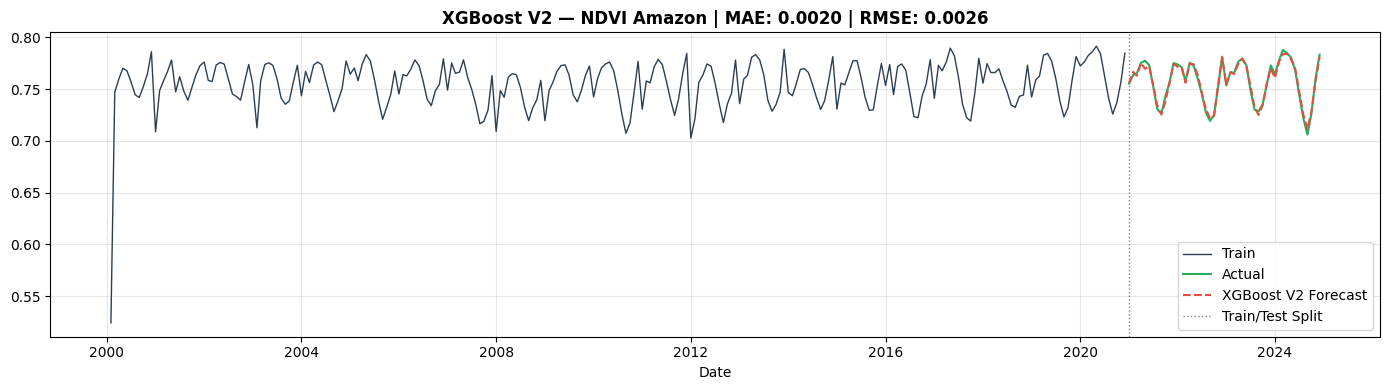


Fitting XGBoost V2 for NDVI Sahel...
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
  Top 5 features: ['month_sin', 'lag_12', 'month_cos', 'lag_6', 'rolling_std_3']


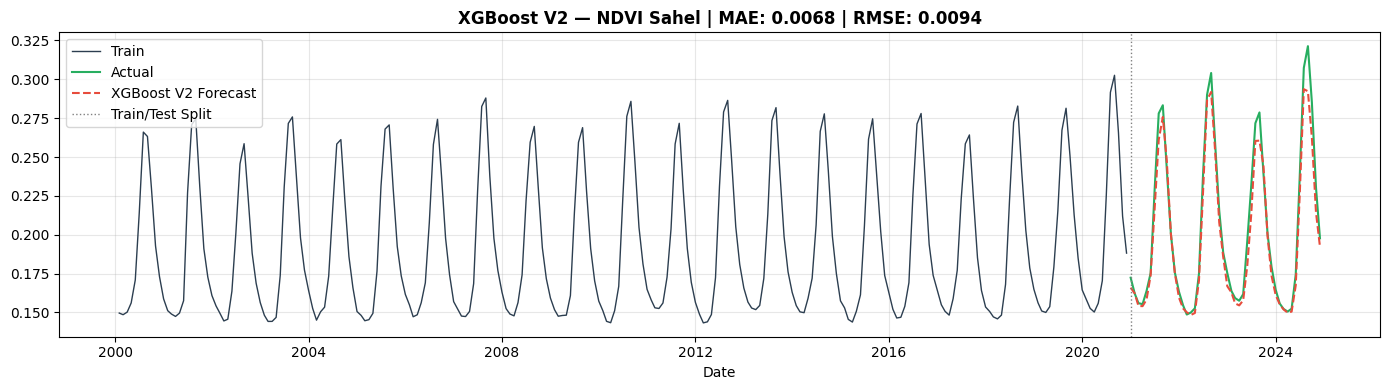


Fitting XGBoost V2 for SST North Atlantic...
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
  Top 5 features: ['lag_6', 'lag_12', 'rolling_std_3', 'month_sin', 'yoy_diff']


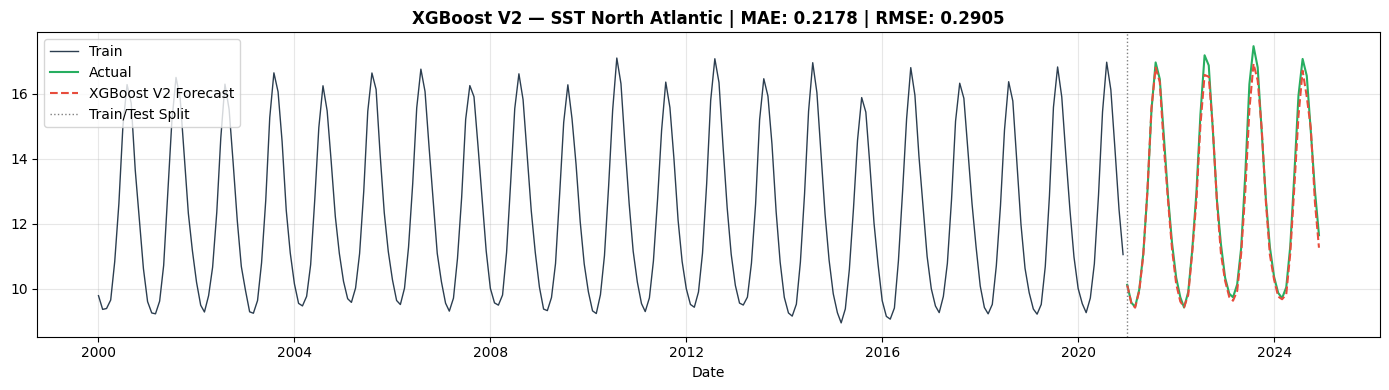


Fitting XGBoost V2 for SST Indian Ocean...
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
  Top 5 features: ['lag_12', 'yoy_diff', 'month_cos', 'rolling_mean_3', 'lag_1']


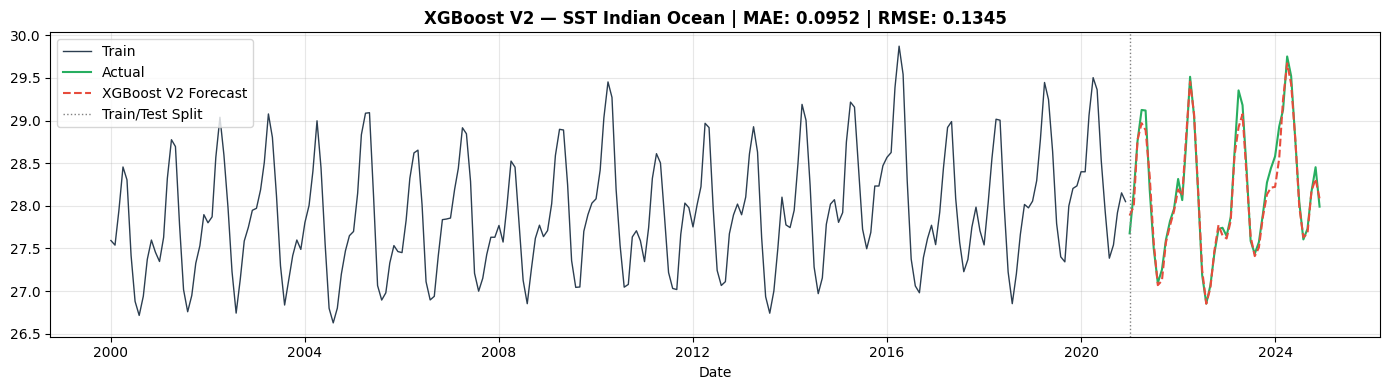


=== XGBoost V2 Results ===
            series                                                                                             best_params    MAE   RMSE top_feature
       NDVI Amazon  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8} 0.0020 0.0026      lag_12
        NDVI Sahel  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8} 0.0068 0.0094   month_sin
SST North Atlantic  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8} 0.2178 0.2905       lag_6
  SST Indian Ocean {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8} 0.0952 0.1345      lag_12


In [5]:
# ============================================================
# XGBoost V2 — Tuned hyperparameters + extended feature set
# Improvements over V1 (default XGBoost, basic lag features):
#   - Extended lag features: lag 1,2,3,6,12,24 months
#   - Rolling statistics: 3-month and 12-month rolling mean/std
#   - Explicit calendar features: month, quarter, year
#   - XGBoost hyperparameter tuning via GridSearchCV
#   - TimeSeriesSplit cross-validation (no data leakage)
# Reference: Chen & Guestrin (2016) KDD
#            Cerqueira et al. (2020) Machine Learning
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler

def create_features_v2(df, value_col):
    """Extended feature engineering for XGBoost V2."""
    df = df.copy()
    
    # Calendar features
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Lag features — short, medium, seasonal, long-seasonal
    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df[value_col].shift(lag)
    
    # Rolling statistics — capture local trend and variability
    df['rolling_mean_3'] = df[value_col].shift(1).rolling(3).mean()
    df['rolling_mean_12'] = df[value_col].shift(1).rolling(12).mean()
    df['rolling_std_3'] = df[value_col].shift(1).rolling(3).std()
    df['rolling_std_12'] = df[value_col].shift(1).rolling(12).std()
    
    # Year-over-year difference — captures inter-annual trend
    df['yoy_diff'] = df[value_col] - df[value_col].shift(12)
    
    df = df.dropna()
    return df

def run_xgboost_v2(train, test, value_col, series_name):
    print(f"\nFitting XGBoost V2 for {series_name}...")
    
    # Combine for feature creation (then re-split)
    full = pd.concat([train, test], ignore_index=True)
    full = create_features_v2(full, value_col)
    
    feature_cols = [c for c in full.columns 
                if c not in ['date', value_col, 'region']
                and full[c].dtype in ['int64', 'float64']]
    
    # Re-split after feature engineering
    train_fe = full[full['date'] <= train['date'].max()]
    test_fe  = full[full['date'] > train['date'].max()]
    
    X_train = train_fe[feature_cols]
    y_train = train_fe[value_col]
    X_test  = test_fe[feature_cols]
    y_test  = test_fe[value_col].values
    
    # TimeSeriesSplit — respects temporal ordering (no leakage)
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Hyperparameter grid
    param_grid = {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    
    xgb = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        verbosity=0
    )
    
    grid_search = GridSearchCV(
        xgb,
        param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    print(f"  Best params: {best_params}")
    
    # Refit best model
    best_model = grid_search.best_estimator_
    forecast = best_model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, forecast)
    rmse = np.sqrt(mean_squared_error(y_test, forecast))
    
    # Feature importance — top 10
    importances = pd.Series(
        best_model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)
    print(f"  Top 5 features: {list(importances.head(5).index)}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test_fe['date'], y_test,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test_fe['date'], forecast,
            color='#e74c3c', linewidth=1.5, linestyle='--',
            label='XGBoost V2 Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'XGBoost V2 — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_xgboost_v2_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'series': series_name,
        'best_params': str(best_params),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'top_feature': importances.index[0]
    }

# Run V2 on all four series
results_xgb_v2 = []

results_xgb_v2.append(run_xgboost_v2(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon'))

results_xgb_v2.append(run_xgboost_v2(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel'))

results_xgb_v2.append(run_xgboost_v2(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic'))

results_xgb_v2.append(run_xgboost_v2(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean'))

# Results table
results_xgb_v2_df = pd.DataFrame(results_xgb_v2)
print("\n=== XGBoost V2 Results ===")
print(results_xgb_v2_df.to_string(index=False))